In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('./data/pet_adoption_data.csv')

X = df.drop('AdoptionLikelihood', axis=1)
y = df['AdoptionLikelihood']
X.drop('PetID', axis=1, inplace=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [2]:
kategoryczne = ['PetType', 'Breed', 'Color', 'Size']

ciągłe = ["AgeMonths", "WeightKg", "AdoptionFee", "DaysInShelter"]

bin = ['Vaccinated', "HealthCondition", "PreviosOwner"]


In [3]:
from sklearn.metrics import make_scorer
import numpy as np

def shelter_score(y_true, y_prob, budget=200, cost=10):
    if y_prob.ndim == 2:
        y_prob = y_prob[:, 1]
    
    n_ads = budget // cost
    top_idx = y_prob.argsort()[-n_ads:]
    chosen_true = np.array(y_true)[top_idx]
    
    expected_adoptions = chosen_true.sum() * 0.70 + (n_ads - chosen_true.sum()) * 0.10
    return float(expected_adoptions)

scorer = make_scorer(shelter_score, response_method='predict_proba')

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import precision_score



preprocessor = ColumnTransformer([
    ('num', KBinsDiscretizer(encode='ordinal', quantile_method='averaged_inverted_cdf'), ["AgeMonths", "WeightKg", "AdoptionFee", "TimeInShelterDays"]),
    ('cat', OrdinalEncoder(), ['PetType', 'Breed', 'Color', 'Size']),
    ('bin', 'passthrough', ['Vaccinated', "HealthCondition", "PreviousOwner"])
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', CategoricalNB())
])

alpha = [0.01, 0.10, 0.20, 0.50, 1.0]


n_bins = range(2, 11)
#2, 3, ..., 10

param_grid = {
    'prep__num__strategy': ['kmeans' ,'quantile'],
    'prep__num__n_bins': n_bins,
    'model__alpha': alpha
}

grid_search_scorer = GridSearchCV(pipeline, param_grid, cv=5, scoring=scorer)
grid_search_scorer.fit(X_train, y_train)

grid_search_precision = GridSearchCV(pipeline, param_grid, cv=5, scoring="precision")
grid_search_precision.fit(X_train, y_train)

print(f"Najlepsze parametry dla scorer: {grid_search_scorer.best_params_}")
print("Najlepszy wynik na zbiorze treningowym scorer:", grid_search_scorer.best_score_)

model_scorer = grid_search_scorer.best_estimator_
y_pred_scorer = model_scorer.predict_proba(X_test)

number = shelter_score(y_test, y_pred_scorer)
print(f"Liczba na zbiorze testowym: {number}")

print(f"Najlepsze parametry dla precision: {grid_search_precision.best_params_}")
print("Najlepszy wynik na zbiorze treningowym precision:", grid_search_precision.best_score_)

model_precision = grid_search_precision.best_estimator_
y_pred_precision_bin = model_precision.predict(X_test)
y_pred_precision = model_precision.predict_proba(X_test)

precision = precision_score(y_test, y_pred_precision_bin)
print(f"Liczba precision na zbiorze testowym: {precision}")

number = shelter_score(y_test, y_pred_precision)
print(f"Faktyczna liczba na zbiorze testowym: {number}")

Najlepsze parametry dla scorer: {'model__alpha': 0.01, 'prep__num__n_bins': 2, 'prep__num__strategy': 'kmeans'}
Najlepszy wynik na zbiorze treningowym scorer: 13.4
Liczba na zbiorze testowym: 12.799999999999999
Najlepsze parametry dla precision: {'model__alpha': 0.01, 'prep__num__n_bins': 9, 'prep__num__strategy': 'quantile'}
Najlepszy wynik na zbiorze treningowym precision: 0.9311802438503041
Liczba precision na zbiorze testowym: 0.8796296296296297
Faktyczna liczba na zbiorze testowym: 14.0


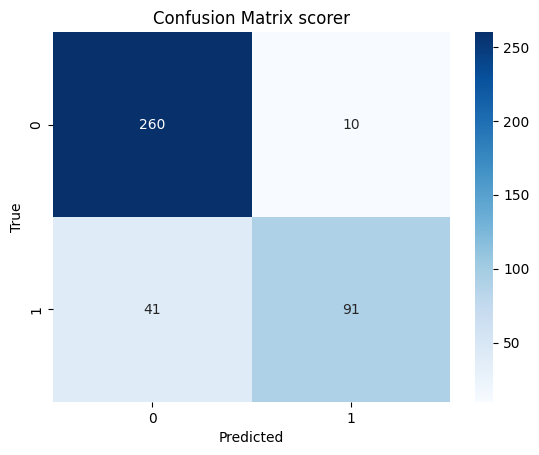

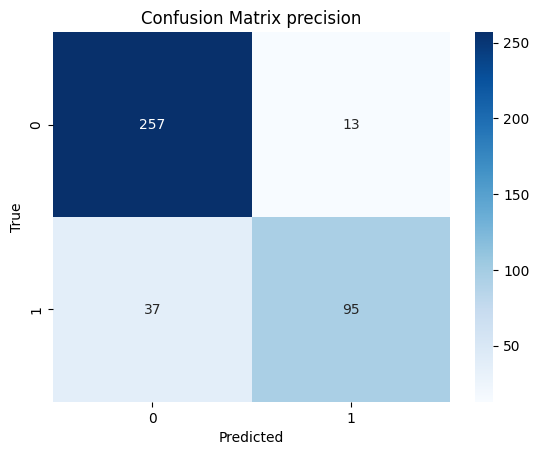

In [5]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

y_pred_scorer_bin = model_scorer.predict(X_test)

cm = confusion_matrix(y_test, y_pred_scorer_bin)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix scorer')
plt.show()

cm = confusion_matrix(y_test, y_pred_precision_bin)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix precision')
plt.show()

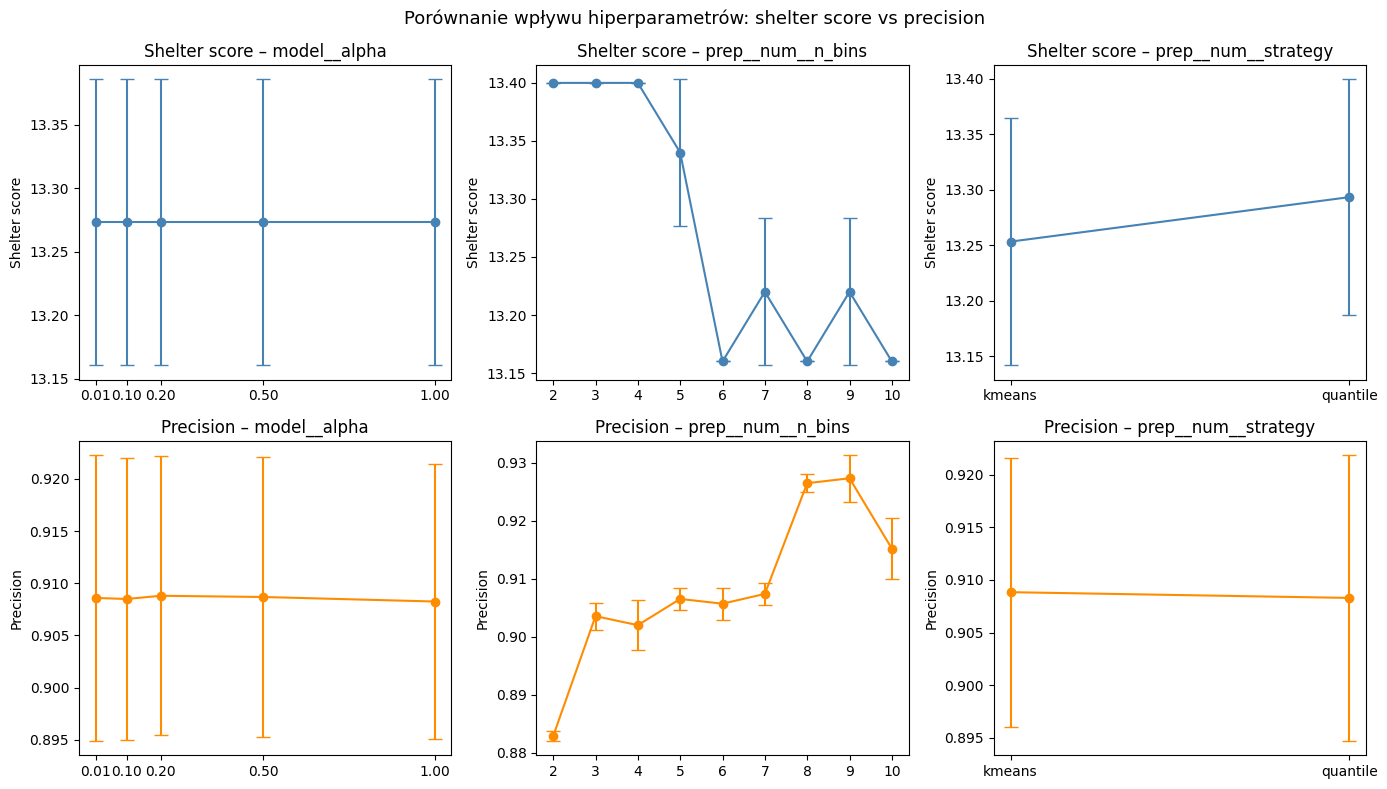

In [ ]:
results_shelter = pd.DataFrame(grid_search_scorer.cv_results_)
results_precision = pd.DataFrame(grid_search_precision.cv_results_)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

params = ['param_model__alpha', 'param_prep__num__n_bins', 'param_prep__num__strategy']

for col, param in enumerate(params):
    ax = axes[0, col]
    grouped = results_shelter.groupby(param)['mean_test_score'].agg(['mean', 'std'])
    if grouped.index.dtype == object:
        ax.bar(grouped.index, grouped['mean'], yerr=grouped['std'], capsize=5, color='steelblue')
    else:
        ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'],
                    marker='o', capsize=5, color='steelblue')
        ax.set_xticks(grouped.index)
    ax.set_title(f'Shelter score – {param.replace("param_", "")}')
    ax.set_ylabel('Shelter score')

    
    ax = axes[1, col]
    grouped = results_precision.groupby(param)['mean_test_score'].agg(['mean', 'std'])
    if grouped.index.dtype == object:
        ax.bar(grouped.index, grouped['mean'], yerr=grouped['std'], capsize=5, color='darkorange')
    else:
        ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'],
                    marker='o', capsize=5, color='darkorange')
        ax.set_xticks(grouped.index)
    ax.set_title(f'Precision – {param.replace("param_", "")}')
    ax.set_ylabel('Precision')

plt.suptitle('Porównanie wpływu hiperparametrów: shelter score vs precision', fontsize=13)
plt.tight_layout()
plt.show()

Różnica między dobrym a złym kandydatem jest na tyle duża że ranking top 20 nie zmienia się niezależnie od alphy, n_bins czy strategy.

In [10]:
import joblib
joblib.dump(model_precision, 'NB_shelter_model.pkl')

['NB_shelter_model.pkl']